# Unsupervised Learning Methods with topologic_fast and Graphs

This notebook demonstrates unsupervised learning methods applied to topological data and graphs using `topologic_fast`.

## Overview

Unsupervised learning on topological data involves:
- Clustering spatial data points
- Graph-based analysis (centrality, community detection)
- Dimensionality reduction for topology features

In this notebook, we'll:
1. Create a spatial grid and derive graphs from topology
2. Apply clustering algorithms (K-Means, DBSCAN, HDBSCAN)
3. Perform graph analysis (centrality measures, shortest paths)
4. Visualize results using Plotly

In [1]:
# Import required libraries
import topologic_fast as tf
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans, DBSCAN
import warnings
warnings.filterwarnings('ignore')

# Check for HDBSCAN
try:
    from sklearn.cluster import HDBSCAN
    HDBSCAN_AVAILABLE = True
    print("HDBSCAN is available (scikit-learn >= 1.3)")
except ImportError:
    try:
        import hdbscan
        HDBSCAN_AVAILABLE = True
        print("HDBSCAN is available (hdbscan package)")
    except ImportError:
        HDBSCAN_AVAILABLE = False
        print("HDBSCAN not available. Install with: pip install hdbscan")

HDBSCAN is available (scikit-learn >= 1.3)


## 1. Create a Floor Plan and Grid

We'll simulate a gallery floor plan by creating a shell (collection of faces) and overlaying a grid for spatial analysis.

In [2]:
# Create a simple gallery floor plan using faces
# Main gallery hall
main_hall = tf.Face.Rectangle(x=50, y=35, z=0, width=80, length=50)

# Side rooms
room1 = tf.Face.Rectangle(x=15, y=20, z=0, width=25, length=25)
room2 = tf.Face.Rectangle(x=15, y=50, z=0, width=25, length=25)
room3 = tf.Face.Rectangle(x=85, y=20, z=0, width=25, length=25)
room4 = tf.Face.Rectangle(x=85, y=50, z=0, width=25, length=25)

# Corridor
corridor = tf.Face.Rectangle(x=50, y=70, z=0, width=40, length=10)

rooms = [main_hall, room1, room2, room3, room4, corridor]

print(f"Created {len(rooms)} room faces")
for i, room in enumerate(rooms):
    print(f"  Room {i}: Area = {room.Area():.2f}")

Created 6 room faces
  Room 0: Area = 4000.00
  Room 1: Area = 625.00
  Room 2: Area = 625.00
  Room 3: Area = 625.00
  Room 4: Area = 625.00
  Room 5: Area = 400.00


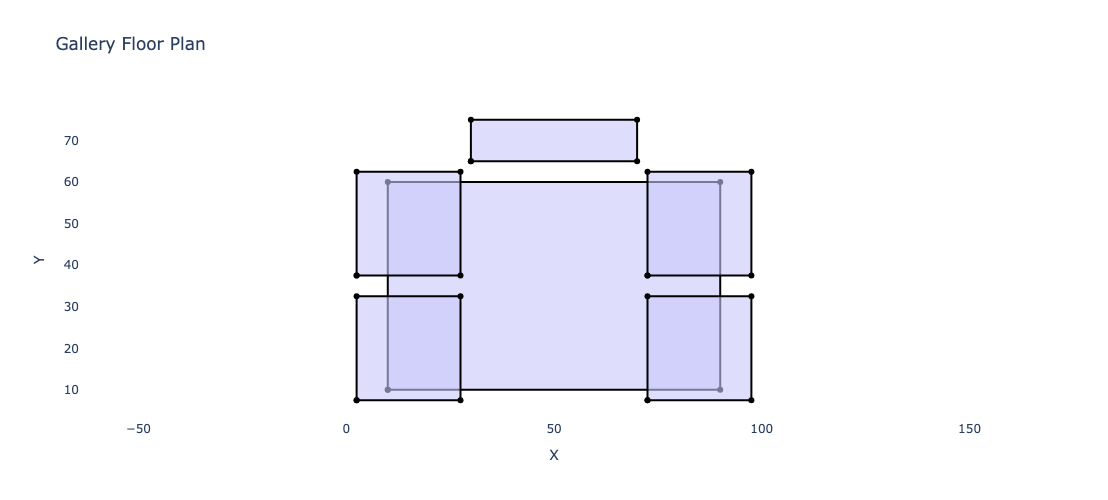

In [3]:
def visualize_faces_2d(faces, title="Floor Plan", colors=None):
    """Visualize faces in 2D."""
    fig = go.Figure()
    
    if colors is None:
        colors = ['rgba(200, 200, 250, 0.6)'] * len(faces)
    
    for i, face in enumerate(faces):
        vertices = face.Vertices()
        xs = [v.X() for v in vertices] + [vertices[0].X()]
        ys = [v.Y() for v in vertices] + [vertices[0].Y()]
        
        fig.add_trace(go.Scatter(
            x=xs, y=ys,
            fill='toself',
            fillcolor=colors[i] if isinstance(colors, list) else colors,
            line=dict(color='black', width=2),
            name=f'Room {i}'
        ))
    
    fig.update_layout(
        title=title,
        xaxis_title="X",
        yaxis_title="Y",
        width=700,
        height=500,
        yaxis=dict(scaleanchor='x'),
        plot_bgcolor='white',
        showlegend=False
    )
    
    return fig

fig = visualize_faces_2d(rooms, "Gallery Floor Plan")
fig.show()

## 2. Create a Grid of Points for Spatial Analysis

We'll create a grid of points within the floor plan for clustering and graph analysis.

In [4]:
def create_grid_points(faces, grid_size=5):
    """Create a grid of points within the bounding box of faces."""
    # Get overall bounding box
    all_vertices = []
    for face in faces:
        all_vertices.extend(face.Vertices())
    
    xs = [v.X() for v in all_vertices]
    ys = [v.Y() for v in all_vertices]
    
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)
    
    # Create grid points
    grid_points = []
    x_range = np.arange(xmin, xmax + grid_size, grid_size)
    y_range = np.arange(ymin, ymax + grid_size, grid_size)
    
    for x in x_range:
        for y in y_range:
            grid_points.append([x, y, 0])
    
    return np.array(grid_points)

# Create grid points
grid_points = create_grid_points(rooms, grid_size=5)
print(f"Created {len(grid_points)} grid points")

# Convert to topologic vertices
grid_vertices = [tf.Vertex.ByCoordinates(p[0], p[1], p[2]) for p in grid_points]

Created 300 grid points


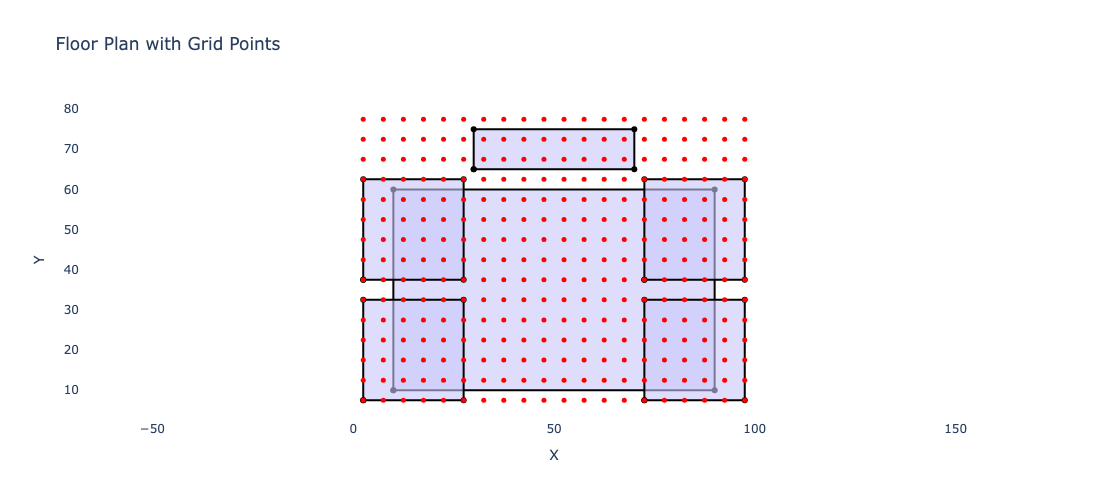

In [5]:
# Visualize grid points on floor plan
fig = visualize_faces_2d(rooms, "Floor Plan with Grid Points")

fig.add_trace(go.Scatter(
    x=grid_points[:, 0],
    y=grid_points[:, 1],
    mode='markers',
    marker=dict(size=5, color='red'),
    name='Grid Points'
))

fig.show()

## 3. K-Means Clustering

K-Means partitions data into K clusters by minimizing within-cluster variance.

In [6]:
# Apply K-Means clustering
k = 6  # Number of rooms/regions
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(grid_points[:, :2])
km_centroids = kmeans.cluster_centers_

print(f"K-Means clustering with k={k}")
print(f"Cluster sizes: {[np.sum(km_labels == i) for i in range(k)]}")

K-Means clustering with k=6
Cluster sizes: [np.int64(52), np.int64(51), np.int64(56), np.int64(46), np.int64(49), np.int64(46)]


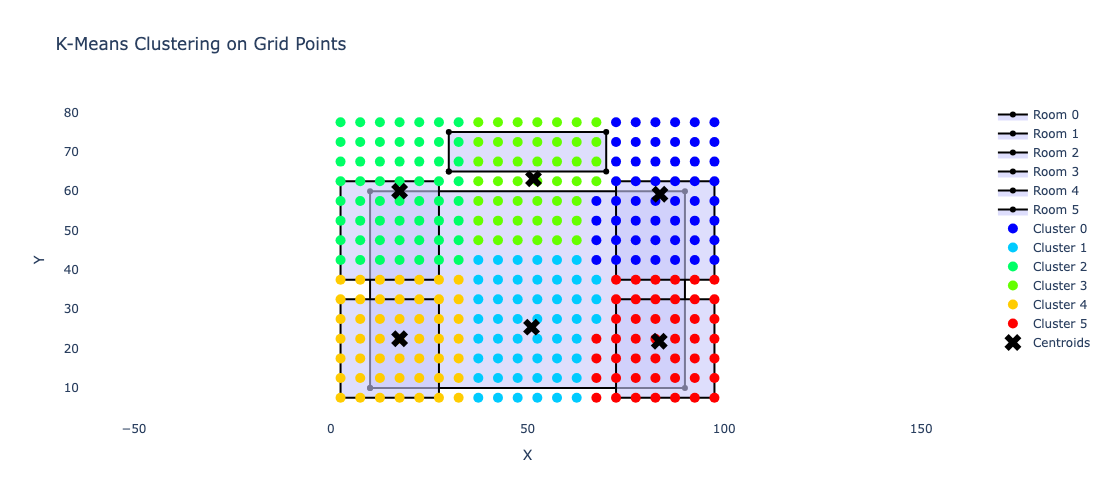

In [7]:
def get_thermal_color(value, vmin=0, vmax=1):
    """Convert a value to a thermal colormap color."""
    # Normalize value
    t = (value - vmin) / (vmax - vmin + 1e-10)
    t = max(0, min(1, t))
    
    # Simple thermal colormap (blue -> cyan -> yellow -> red)
    if t < 0.25:
        r, g, b = 0, int(255 * t * 4), 255
    elif t < 0.5:
        r, g, b = 0, 255, int(255 * (1 - (t - 0.25) * 4))
    elif t < 0.75:
        r, g, b = int(255 * (t - 0.5) * 4), 255, 0
    else:
        r, g, b = 255, int(255 * (1 - (t - 0.75) * 4)), 0
    
    return f'rgb({r},{g},{b})'

# Visualize K-Means results
colors = [get_thermal_color(label, 0, k-1) for label in km_labels]

fig = visualize_faces_2d(rooms, "K-Means Clustering on Grid Points")

# Add clustered points
for cluster_id in range(k):
    mask = km_labels == cluster_id
    cluster_points = grid_points[mask]
    color = get_thermal_color(cluster_id, 0, k-1)
    
    fig.add_trace(go.Scatter(
        x=cluster_points[:, 0],
        y=cluster_points[:, 1],
        mode='markers',
        marker=dict(size=10, color=color),
        name=f'Cluster {cluster_id}'
    ))

# Add centroids
fig.add_trace(go.Scatter(
    x=km_centroids[:, 0],
    y=km_centroids[:, 1],
    mode='markers',
    marker=dict(size=15, color='black', symbol='x'),
    name='Centroids'
))

fig.update_layout(showlegend=True)
fig.show()

## 4. DBSCAN Clustering

DBSCAN finds clusters based on density, without requiring the number of clusters as input.

In [8]:
# Apply DBSCAN with different epsilon values
epsilon = 8
min_samples = 3

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
db_labels = dbscan.fit_predict(grid_points[:, :2])

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"DBSCAN (eps={epsilon}, min_samples={min_samples})")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points: {n_noise}")

DBSCAN (eps=8, min_samples=3)
  Clusters found: 1
  Noise points: 0


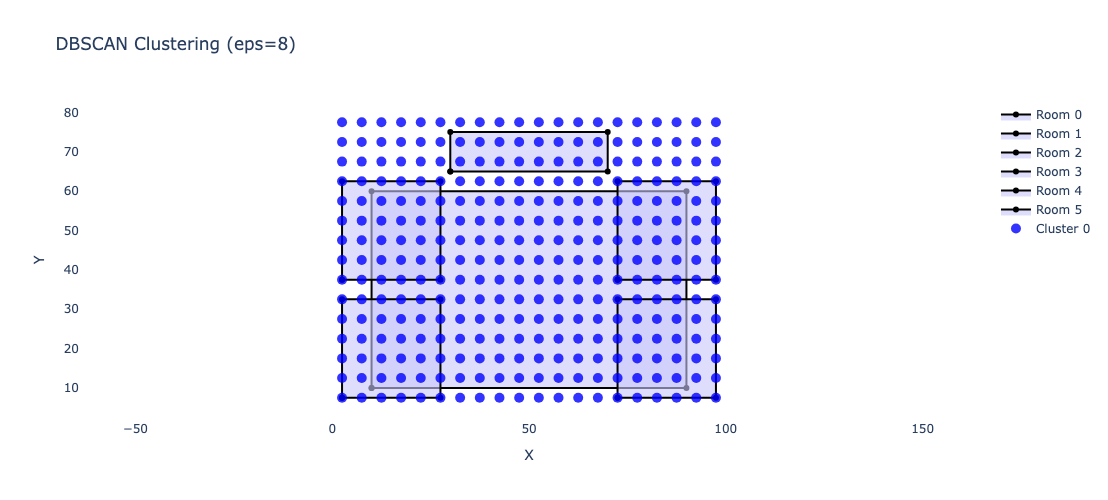

In [9]:
# Visualize DBSCAN results
fig = visualize_faces_2d(rooms, f"DBSCAN Clustering (eps={epsilon})")

unique_labels = set(db_labels)
for label in unique_labels:
    mask = db_labels == label
    cluster_points = grid_points[mask]
    
    if label == -1:
        color = 'gray'
        name = 'Noise'
    else:
        color = get_thermal_color(label, 0, max(1, n_clusters-1))
        name = f'Cluster {label}'
    
    fig.add_trace(go.Scatter(
        x=cluster_points[:, 0],
        y=cluster_points[:, 1],
        mode='markers',
        marker=dict(size=10, color=color, opacity=0.8 if label >= 0 else 0.4),
        name=name
    ))

fig.update_layout(showlegend=True)
fig.show()

## 5. HDBSCAN Clustering

HDBSCAN extends DBSCAN by building a cluster hierarchy and extracting stable clusters automatically. It does not require an epsilon parameter.

**Note:** HDBSCAN is not yet implemented in topologic_fast. We use scikit-learn's implementation here.

In [10]:
if HDBSCAN_AVAILABLE:
    # Try sklearn's HDBSCAN first
    try:
        from sklearn.cluster import HDBSCAN as HDBSCAN_sklearn
        hdb = HDBSCAN_sklearn(min_cluster_size=5)
    except ImportError:
        import hdbscan as hdb_lib
        hdb = hdb_lib.HDBSCAN(min_cluster_size=5)
    
    hdb_labels = hdb.fit_predict(grid_points[:, :2])
    
    n_hdb_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    n_hdb_noise = list(hdb_labels).count(-1)
    
    print("HDBSCAN (no epsilon needed)")
    print(f"  Clusters found: {n_hdb_clusters}")
    print(f"  Noise points: {n_hdb_noise}")
else:
    print("HDBSCAN not available. Skipping this section.")
    print("\nHDBSCAN advantages over DBSCAN:")
    print("  - No epsilon parameter needed")
    print("  - Handles varying density clusters")
    print("  - Automatically determines cluster count")

HDBSCAN (no epsilon needed)
  Clusters found: 2
  Noise points: 19


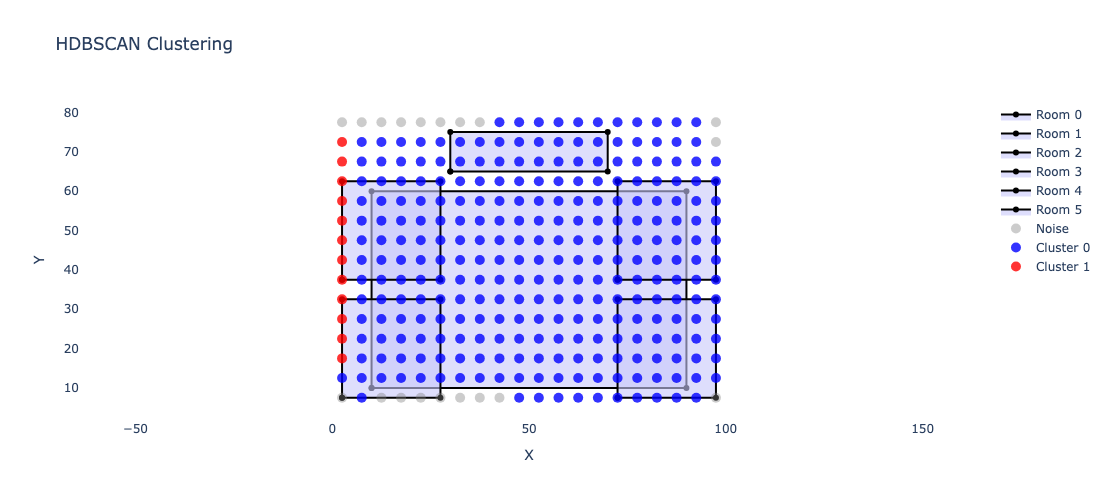

In [11]:
if HDBSCAN_AVAILABLE:
    # Visualize HDBSCAN results
    fig = visualize_faces_2d(rooms, "HDBSCAN Clustering")
    
    unique_labels = set(hdb_labels)
    for label in sorted(unique_labels):
        mask = hdb_labels == label
        cluster_points = grid_points[mask]
        
        if label == -1:
            color = 'gray'
            name = 'Noise'
        else:
            color = get_thermal_color(label, 0, max(1, n_hdb_clusters-1))
            name = f'Cluster {label}'
        
        fig.add_trace(go.Scatter(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            mode='markers',
            marker=dict(size=10, color=color, opacity=0.8 if label >= 0 else 0.4),
            name=name
        ))
    
    fig.update_layout(showlegend=True)
    fig.show()

## 6. Graph-Based Analysis

topologic_fast provides graph utilities for analyzing topology. We can create graphs from topology and compute various metrics.

In [12]:
# Create a graph from grid points
# First, create edges connecting neighboring points
def create_grid_graph(points, spacing):
    """Create a graph from grid points with edges to neighbors."""
    vertices = [tf.Vertex.ByCoordinates(p[0], p[1], p[2]) for p in points]
    edges = []
    
    # Connect to neighbors within spacing * 1.5
    threshold = spacing * 1.5
    
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            dist = np.linalg.norm(points[i, :2] - points[j, :2])
            if dist < threshold:
                edge = tf.Edge.ByStartVertexEndVertex(vertices[i], vertices[j])
                edges.append(edge)
    
    graph = tf.Graph.ByVerticesEdges(vertices, edges)
    return graph, vertices

# Create graph
grid_graph, graph_vertices = create_grid_graph(grid_points, spacing=5)

print(f"Grid Graph:")
print(f"  Vertices: {grid_graph.Order()}")
print(f"  Edges: {grid_graph.Size()}")
print(f"  Density: {grid_graph.Density():.4f}")

Grid Graph:
  Vertices: 300
  Edges: 1097
  Density: 0.0245


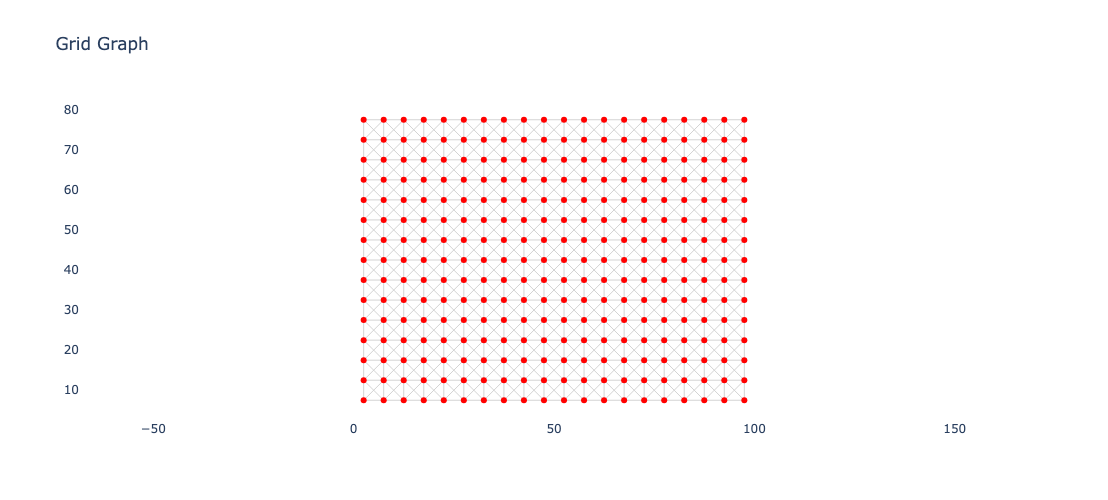

In [13]:
# Visualize the graph
def visualize_graph_2d(graph, title="Graph"):
    """Visualize a graph in 2D."""
    fig = go.Figure()
    
    # Draw edges
    edges = graph.Edges()
    edge_x = []
    edge_y = []
    
    for edge in edges:
        start, end = edge.Vertices()
        edge_x.extend([start.X(), end.X(), None])
        edge_y.extend([start.Y(), end.Y(), None])
    
    fig.add_trace(go.Scatter(
        x=edge_x, y=edge_y,
        mode='lines',
        line=dict(color='lightgray', width=1),
        name='Edges'
    ))
    
    # Draw vertices
    vertices = graph.Vertices()
    vx = [v.X() for v in vertices]
    vy = [v.Y() for v in vertices]
    
    fig.add_trace(go.Scatter(
        x=vx, y=vy,
        mode='markers',
        marker=dict(size=6, color='red'),
        name='Vertices'
    ))
    
    fig.update_layout(
        title=title,
        width=700,
        height=500,
        yaxis=dict(scaleanchor='x'),
        plot_bgcolor='white',
        showlegend=False
    )
    
    return fig

fig = visualize_graph_2d(grid_graph, "Grid Graph")
fig.show()

## 7. Shortest Path Analysis

We can find shortest paths between vertices in the graph.

In [14]:
# Find shortest path between two corners of the grid
vertices = grid_graph.Vertices()

if len(vertices) >= 2:
    # Find corner vertices
    coords = np.array([v.Coordinates() for v in vertices])
    
    # Start: bottom-left corner
    start_idx = np.argmin(coords[:, 0] + coords[:, 1])
    start_vertex = vertices[start_idx]
    
    # End: top-right corner
    end_idx = np.argmax(coords[:, 0] + coords[:, 1])
    end_vertex = vertices[end_idx]
    
    print(f"Start: ({start_vertex.X():.1f}, {start_vertex.Y():.1f})")
    print(f"End: ({end_vertex.X():.1f}, {end_vertex.Y():.1f})")
    
    # Find shortest path
    path = grid_graph.Path(start_vertex, end_vertex)
    
    if path:
        path_vertices = path.Vertices()
        print(f"\nShortest path found with {len(path_vertices)} vertices")
        print(f"Path length: {path.Length():.2f}")
    else:
        print("No path found")

Start: (2.5, 7.5)
End: (97.5, 77.5)

Shortest path found with 20 vertices
Path length: 123.99


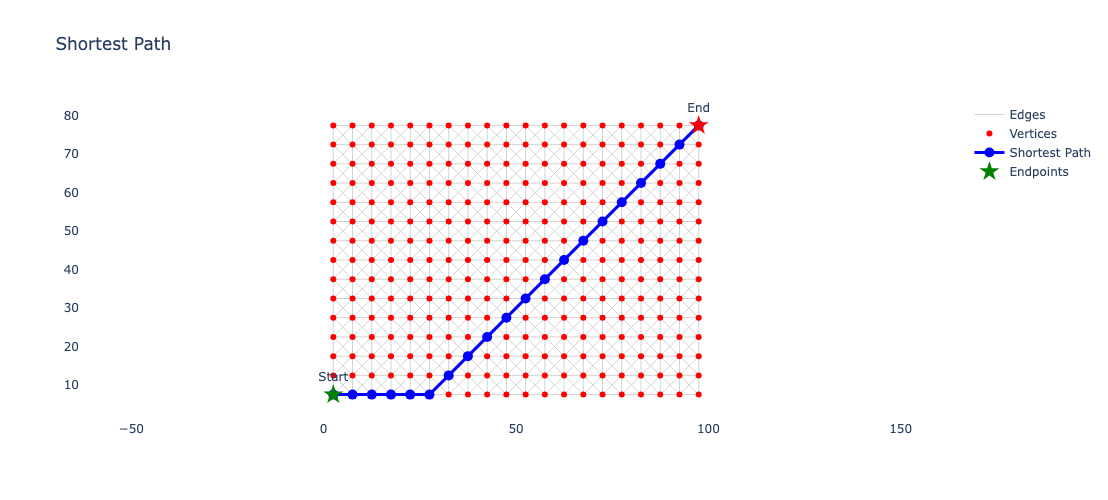

In [15]:
# Visualize shortest path
if path:
    fig = visualize_graph_2d(grid_graph, "Shortest Path")
    
    # Draw path
    path_verts = path.Vertices()
    px = [v.X() for v in path_verts]
    py = [v.Y() for v in path_verts]
    
    fig.add_trace(go.Scatter(
        x=px, y=py,
        mode='lines+markers',
        line=dict(color='blue', width=3),
        marker=dict(size=10, color='blue'),
        name='Shortest Path'
    ))
    
    # Highlight start and end
    fig.add_trace(go.Scatter(
        x=[start_vertex.X(), end_vertex.X()],
        y=[start_vertex.Y(), end_vertex.Y()],
        mode='markers+text',
        marker=dict(size=15, color=['green', 'red'], symbol='star'),
        text=['Start', 'End'],
        textposition='top center',
        name='Endpoints'
    ))
    
    fig.update_layout(showlegend=True)
    fig.show()

## 8. Depth Map / Closeness Centrality

Depth map shows the topological distance from a source vertex to all other vertices. This is related to closeness centrality in space syntax.

In [16]:
# Compute depth map from center vertex
center_idx = len(vertices) // 2
center_vertex = vertices[center_idx]

depth_map = grid_graph.DepthMap(center_vertex)

print(f"Depth map from center vertex ({center_vertex.X():.1f}, {center_vertex.Y():.1f})")
print(f"Max depth: {max(depth_map)}")
print(f"Sample depths: {depth_map[:10]}")

Depth map from center vertex (52.5, 7.5)
Max depth: 14
Sample depths: [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


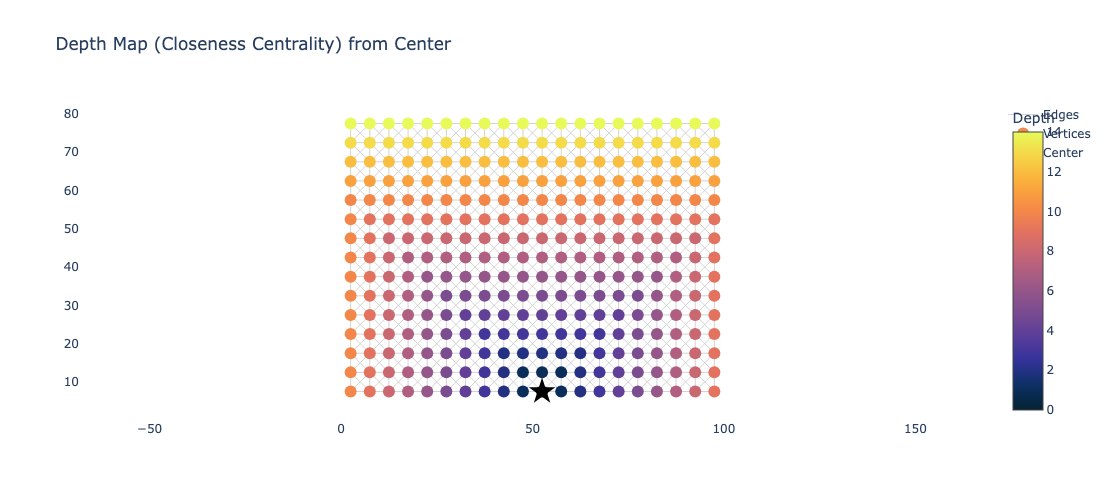

In [17]:
# Visualize depth map
fig = go.Figure()

# Draw edges
edges = grid_graph.Edges()
edge_x = []
edge_y = []
for edge in edges:
    start, end = edge.Vertices()
    edge_x.extend([start.X(), end.X(), None])
    edge_y.extend([start.Y(), end.Y(), None])

fig.add_trace(go.Scatter(
    x=edge_x, y=edge_y,
    mode='lines',
    line=dict(color='lightgray', width=1),
    name='Edges'
))

# Draw vertices colored by depth
max_depth = max(depth_map) if max(depth_map) > 0 else 1
colors = [get_thermal_color(d, 0, max_depth) for d in depth_map]

vx = [v.X() for v in vertices]
vy = [v.Y() for v in vertices]

fig.add_trace(go.Scatter(
    x=vx, y=vy,
    mode='markers',
    marker=dict(size=12, color=depth_map, colorscale='Thermal', showscale=True,
                colorbar=dict(title='Depth')),
    text=[f'Depth: {d}' for d in depth_map],
    hoverinfo='text',
    name='Vertices'
))

# Highlight center
fig.add_trace(go.Scatter(
    x=[center_vertex.X()],
    y=[center_vertex.Y()],
    mode='markers',
    marker=dict(size=20, color='black', symbol='star'),
    name='Center'
))

fig.update_layout(
    title="Depth Map (Closeness Centrality) from Center",
    width=750,
    height=500,
    yaxis=dict(scaleanchor='x'),
    plot_bgcolor='white'
)

fig.show()

## 9. Spiral Data Clustering Demo

Let's demonstrate DBSCAN on spiral data, showing how density-based clustering handles non-convex shapes.

In [18]:
# Create spiral points using topologic_fast
spiral1 = tf.Wire.Spiral(radius_a=1, radius_b=5, height=0, turns=2, sides=50)
spiral1_points = np.array([v.Coordinates() for v in spiral1.Vertices()])

# Create rotated spirals
def rotate_2d(points, angle_deg):
    angle = np.radians(angle_deg)
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    rotation = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
    rotated = points[:, :2] @ rotation.T
    return np.column_stack([rotated, points[:, 2]])

spiral2_points = rotate_2d(spiral1_points, 120)
spiral3_points = rotate_2d(spiral1_points, 240)

all_spiral_points = np.vstack([spiral1_points, spiral2_points, spiral3_points])
print(f"Total spiral points: {len(all_spiral_points)}")

Total spiral points: 303


In [19]:
# Calculate inter-point distance for epsilon
inter_dist = np.linalg.norm(spiral1_points[1] - spiral1_points[0])
print(f"Inter-point distance: {inter_dist:.4f}")

# Apply DBSCAN
spiral_dbscan = DBSCAN(eps=inter_dist * 1.2, min_samples=2)
spiral_labels = spiral_dbscan.fit_predict(all_spiral_points[:, :2])

n_spiral_clusters = len(set(spiral_labels)) - (1 if -1 in spiral_labels else 0)
print(f"DBSCAN found {n_spiral_clusters} clusters")

Inter-point distance: 0.1342
DBSCAN found 3 clusters


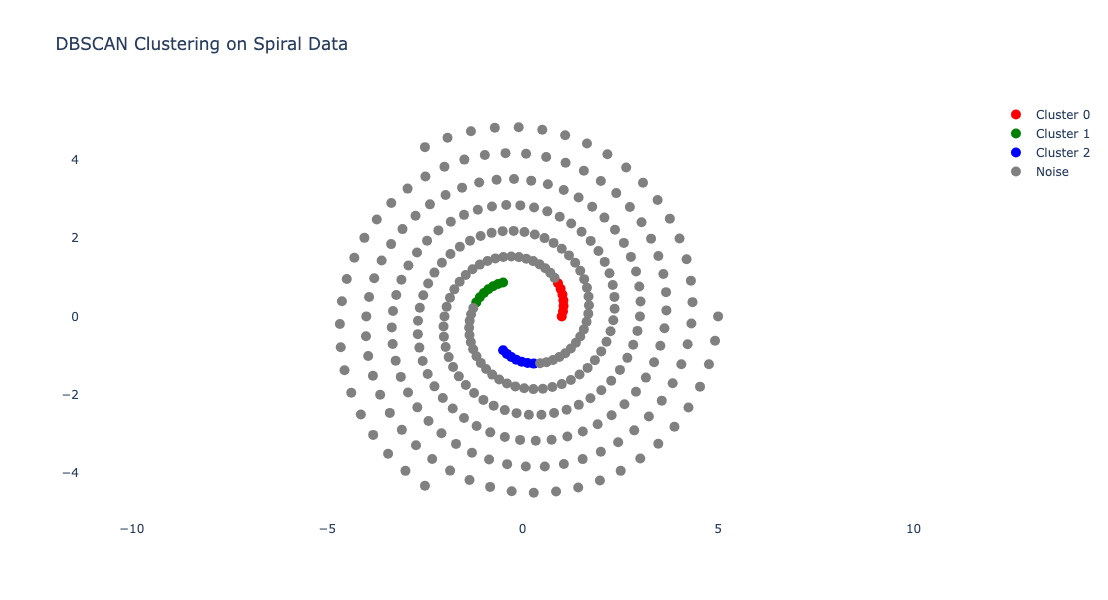

In [20]:
# Visualize spiral clustering
fig = go.Figure()

colors_spiral = ['red', 'green', 'blue', 'orange', 'purple', 'cyan']

for label in set(spiral_labels):
    mask = spiral_labels == label
    cluster_pts = all_spiral_points[mask]
    
    if label == -1:
        color = 'gray'
        name = 'Noise'
    else:
        color = colors_spiral[label % len(colors_spiral)]
        name = f'Cluster {label}'
    
    fig.add_trace(go.Scatter(
        x=cluster_pts[:, 0],
        y=cluster_pts[:, 1],
        mode='markers',
        marker=dict(size=10, color=color),
        name=name
    ))

fig.update_layout(
    title="DBSCAN Clustering on Spiral Data",
    width=600,
    height=600,
    yaxis=dict(scaleanchor='x'),
    plot_bgcolor='white'
)

fig.show()

## 10. Summary

In this notebook, we demonstrated:

1. **Grid creation**: Using topologic_fast to create vertices and extract coordinates for analysis

2. **K-Means clustering**: Partitioning spatial data into K groups

3. **DBSCAN clustering**: Density-based clustering without specifying cluster count

4. **HDBSCAN**: Hierarchical density-based clustering (requires external package)

5. **Graph analysis**: Creating graphs from topology with:
   - Shortest path finding
   - Depth maps / closeness centrality

### Key API Mappings

| topologicpy | topologic_fast | Notes |
|-------------|----------------|-------|
| `Cluster.KMeans()` | `sklearn.cluster.KMeans` | Use scikit-learn |
| `Cluster.DBSCAN()` | `sklearn.cluster.DBSCAN` | Use scikit-learn |
| `Cluster.HDBSCAN()` | `hdbscan` or sklearn | External package |
| `Graph.ByTopology()` | `tf.Graph.ByTopology()` | Available |
| `Graph.ShortestPath()` | `graph.Path()` | Returns Wire |
| `Graph.ClosenessCentrality()` | `graph.DepthMap()` | Compute from depth |
| `Graph.CommunityPartition()` | Not yet implemented | Use networkx |

### Applications

- Space syntax analysis for architecture
- Spatial clustering for urban planning
- Navigation and wayfinding analysis
- Building accessibility studies

In [ ]:
# Clean up
tf.clear_store()
print("Topology store cleared.")